In [ ]:
%load_ext autoreload
%autoreload 2
from Network import Network, Layer
import torch
import random
import matplotlib.pyplot as plt



In [ ]:
# SGD - only use one input
xor_network = Network()
xor_network.layers.append(Layer(2, 3))
xor_network.layers.append(Layer(3, 2, activation_function=torch.nn.Identity()))

inputs = torch.tensor([[[0.0,0.0]], [[0.,1.]], [[1.,0.]], [[1., 1]]])
outputs = torch.tensor([[0], [1], [1], [0]])
mse_errors=[]
for i in range(6000):
    j = random.randint(0,3)
    xor_network.calculate_with_gradient(inputs[j], outputs[j])
    xor_network.update_weights(0.1)
    mse = 0
    for j in range(4):
        mse += (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs[j]),outputs[j])**2)/4
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[9.9945e-01, 5.4677e-04]])
tensor([[5.3206e-04, 9.9947e-01]])
tensor([[5.0137e-04, 9.9950e-01]])
tensor([[0.9960, 0.0040]])


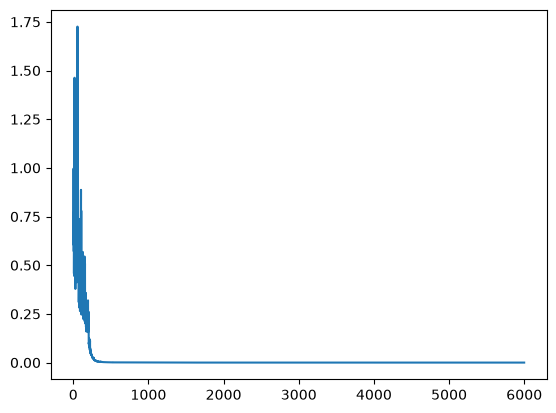

In [ ]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x900 with 11 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >]], dtype=object))

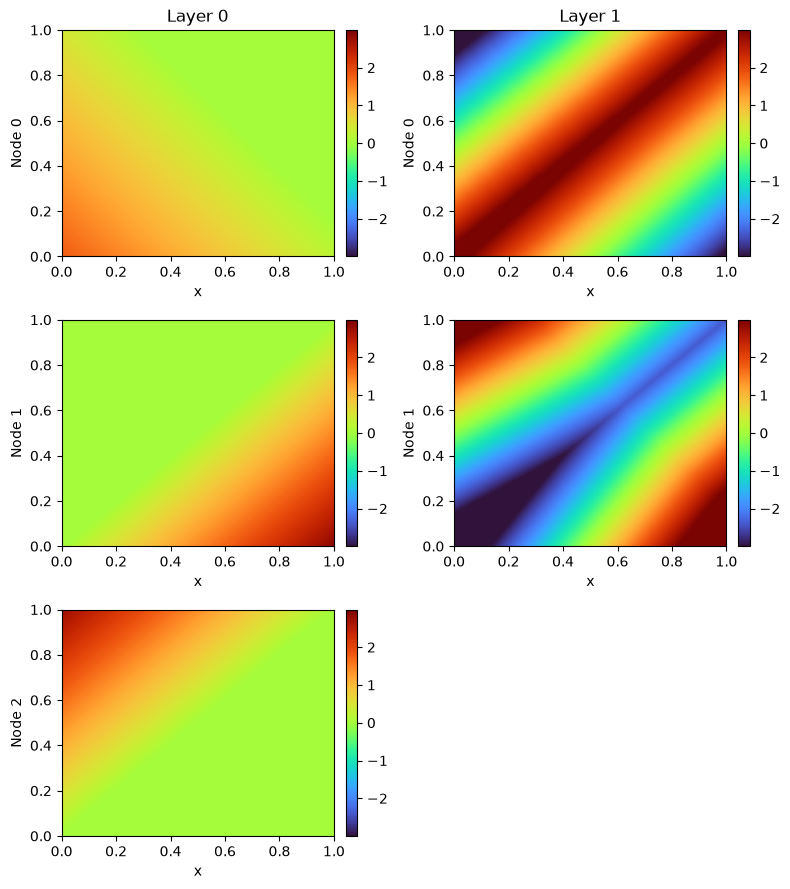

In [ ]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps()

In [ ]:
# Same as above but for sigmoid
xor_network = Network()
xor_network.layers.append(Layer(2, 3, torch.sigmoid))
xor_network.layers.append(Layer(3, 2, torch.nn.Identity()))

inputs = torch.tensor([[[0.0,0.0]], [[0.,1.]], [[1.,0.]], [[1., 1]]])
outputs = torch.tensor([[0], [1], [1], [0]])
mse_errors=[]
for i in range(800):
    for j in random.choices([0, 1, 2, 3], k=1):
        xor_network.calculate_with_gradient(inputs[j], outputs[j])
    
    xor_network.update_weights(1)
    mse = 0
    for j in range(4):
        mse += (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs[j]),outputs[j])**2)/4
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.9624, 0.0376]])
tensor([[5.1953e-04, 9.9948e-01]])
tensor([[0.1216, 0.8784]])
tensor([[0.1160, 0.8840]])


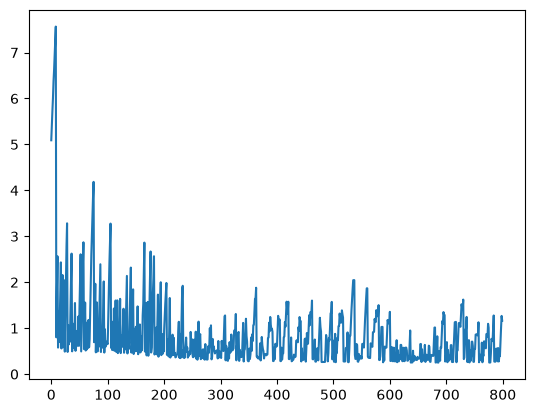

In [ ]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x900 with 11 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >]], dtype=object))

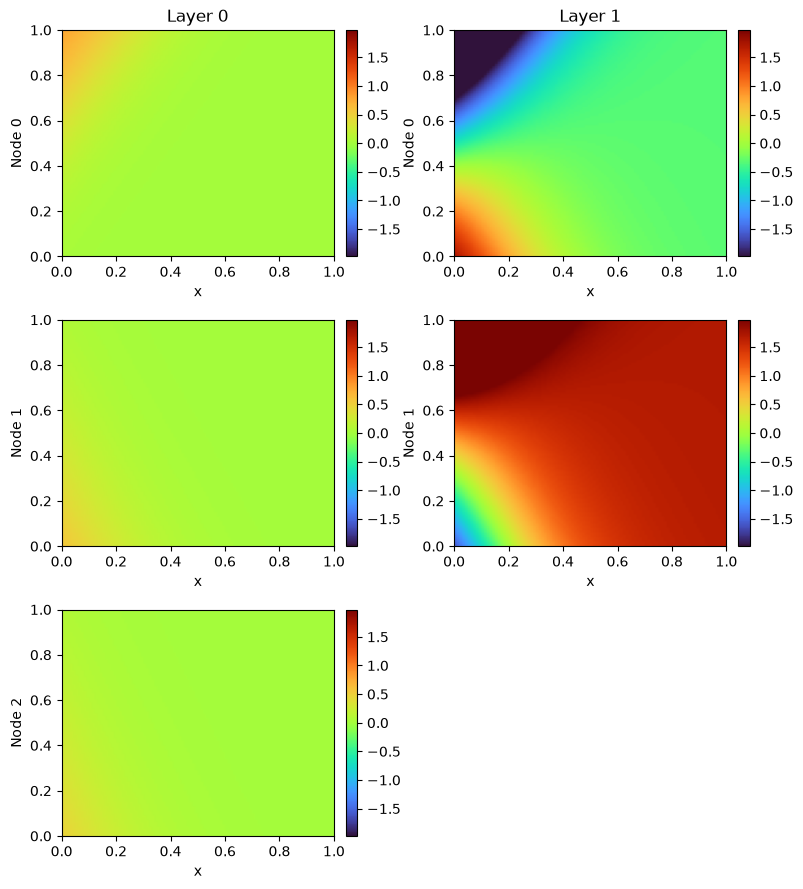

In [ ]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps()

In [ ]:
# Full gradient descent
xor_network = Network()
xor_network.layers.append(Layer(2,3))
xor_network.layers.append(Layer(3,2, torch.nn.Identity()))

inputs = torch.tensor([[[0.0,0.0]], [[0.,1.]], [[1.,0.]], [[1., 1]]])
outputs = torch.tensor([[0], [1], [1], [0]])
mse_errors=[]
for i in range(1000):
    for j in range(4):
        xor_network.calculate_with_gradient(inputs[j], outputs[j])

    xor_network.update_weights(0.1)
    mse = 0
    for j in range(4):
        mse += (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs[j]),outputs[j])**2)/4
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.6651, 0.3349]])
tensor([[0.6651, 0.3349]])
tensor([[0.0048, 0.9952]])
tensor([[0.6651, 0.3349]])


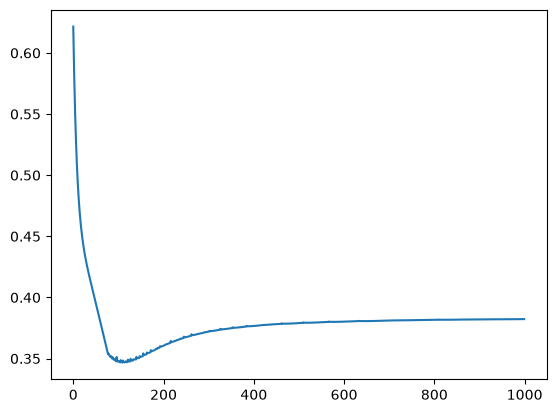

In [ ]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x900 with 11 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >]], dtype=object))

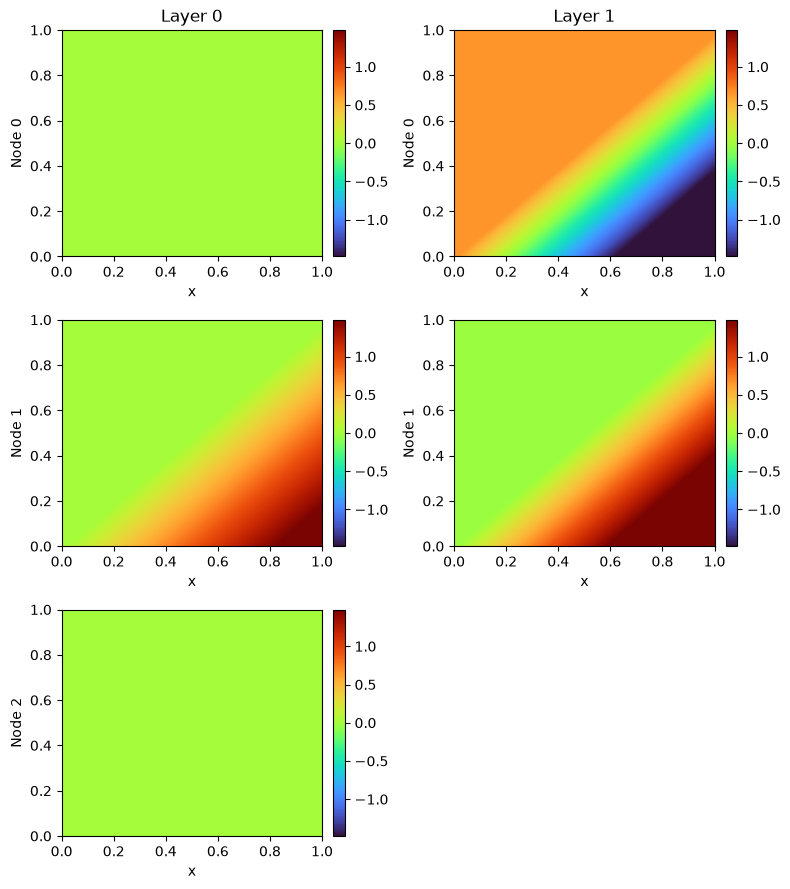

In [ ]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps()

In [ ]:
# Same again but with sigmoid
xor_network = Network()
xor_network.layers.append(Layer(2,3, torch.sigmoid))
xor_network.layers.append(Layer(3,2, torch.nn.Identity()))
inputs = torch.tensor([[[0.0,0.0]], [[0.,1.]], [[1.,0.]], [[1., 1]]])
outputs = torch.tensor([[0], [1], [1], [0]])
mse_errors=[]
for i in range(500):
    for j in range(4):
        xor_network.calculate_with_gradient(inputs[j], outputs[j])

    xor_network.update_weights(1)
    mse = 0
    for j in range(4):
        mse += (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs[j]),outputs[j])**2)/4
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

tensor([[0.9926, 0.0074]])
tensor([[0.0121, 0.9879]])
tensor([[0.0142, 0.9858]])
tensor([[0.9828, 0.0172]])


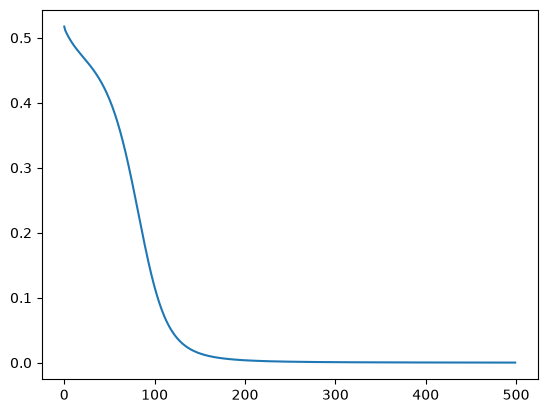

In [ ]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 800x900 with 11 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>, <Axes: >]], dtype=object))

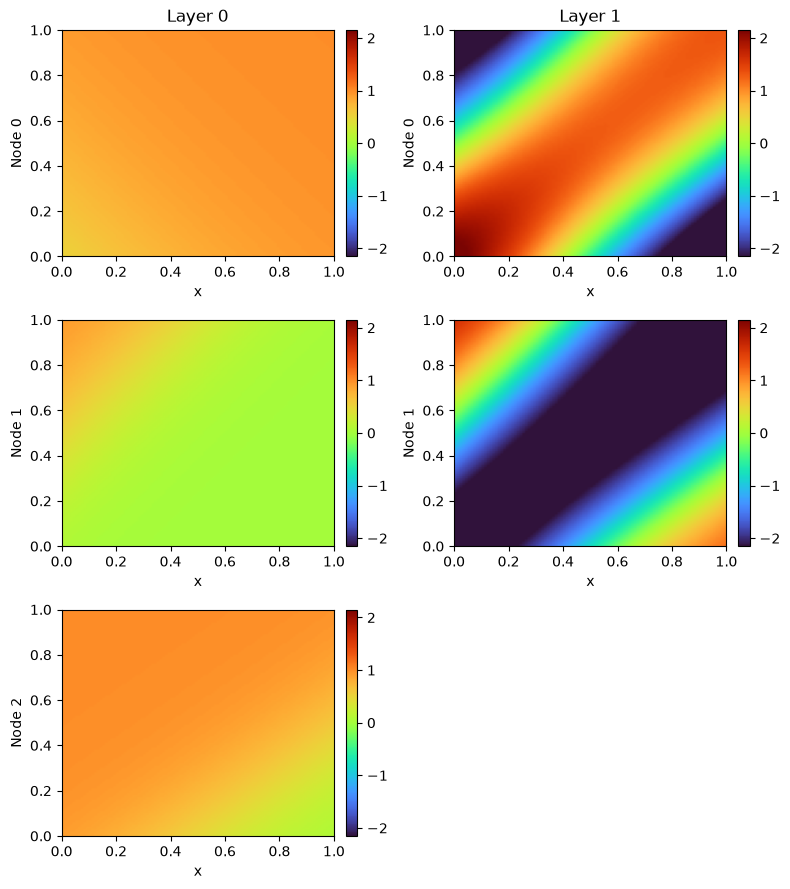

In [ ]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps(robust_clip_percentile=10)

In [ ]:
# Gradient descent but with very wide/deep
xor_network = Network()
xor_network.layers.append(Layer(2,5, torch.sigmoid))
xor_network.layers.append(Layer(5,5, torch.sigmoid))
xor_network.layers.append(Layer(5,5, torch.sigmoid))
xor_network.layers.append(Layer(5,2, torch.nn.Identity()))
inputs = torch.tensor([[[0.0,0.0]], [[0.,1.]], [[1.,0.]], [[1., 1]]])
outputs = torch.tensor([[0], [1], [1], [0]])
mse_errors=[]
for i in range(2000):
    for j in range(4):
        xor_network.calculate_with_gradient(inputs[j], outputs[j])

    xor_network.update_weights(1)
    mse = 0
    for j in range(4):
        mse += (torch.nn.CrossEntropyLoss()(xor_network.calculate(inputs[j]),outputs[j])**2)/4
    mse_errors.append(mse)
for j in range(4):
    print(torch.softmax(xor_network.calculate(inputs[j]), dim=-1))

KeyboardInterrupt: 

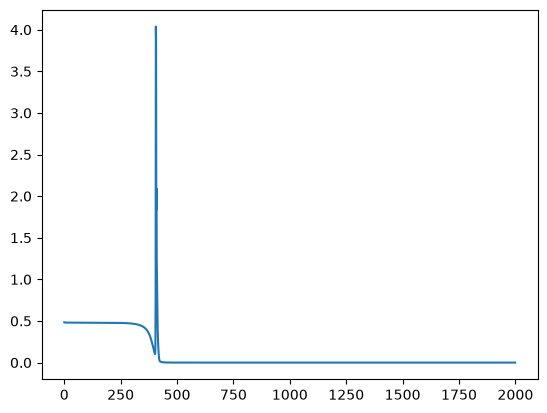

In [ ]:
plt.plot(range(len(mse_errors)), mse_errors)

(<Figure size 1600x1500 with 37 Axes>,
 array([[<Axes: title={'center': 'Layer 0'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 1'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 2'}, xlabel='x', ylabel='Node 0'>,
         <Axes: title={'center': 'Layer 3'}, xlabel='x', ylabel='Node 0'>],
        [<Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>,
         <Axes: xlabel='x', ylabel='Node 1'>],
        [<Axes: xlabel='x', ylabel='Node 2'>,
         <Axes: xlabel='x', ylabel='Node 2'>,
         <Axes: xlabel='x', ylabel='Node 2'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 3'>,
         <Axes: xlabel='x', ylabel='Node 3'>,
         <Axes: xlabel='x', ylabel='Node 3'>, <Axes: >],
        [<Axes: xlabel='x', ylabel='Node 4'>,
         <Axes: xlabel='x', ylabel='Node 4'>,
         <Axes: xlabel='x', ylabel='Node 4'>, <Axes: >]], dtype=object))

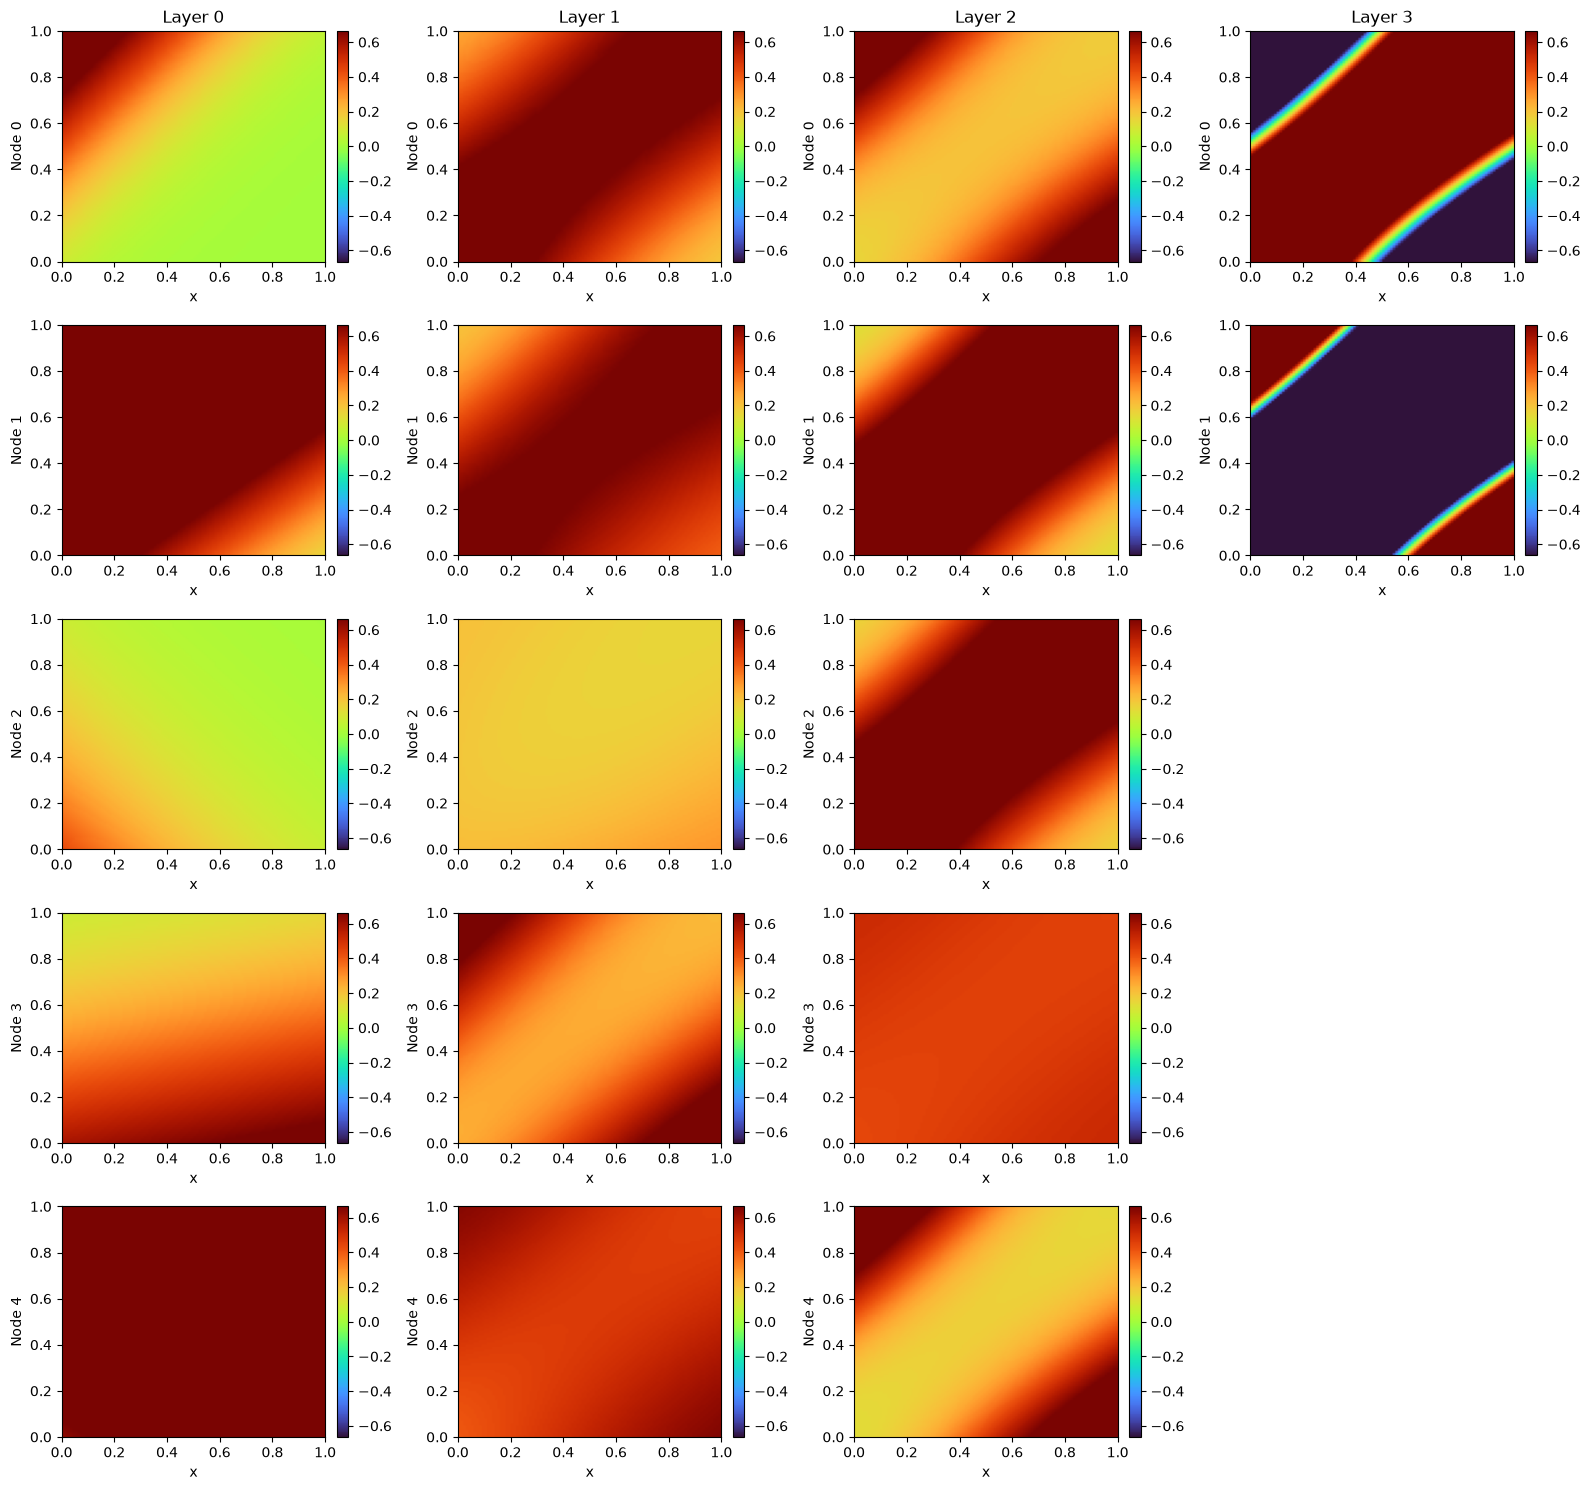

In [ ]:
xor_network.calculate_rectangle((0,0), (1,1), 100);
xor_network.plot_all_layer_heatmaps(robust_clip_percentile=30)